# 0) Enviroment

### Imports and Constants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, learning_curve
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import ElasticNet, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from mord import LogisticAT


DATA_PATH = "../../data/compas_preprocessed.csv"
_RS = 42
_TARGET = "decile_score"
_DROP = "is_recid"
_TEST_PERCENTAGE = 0.2


### Import data and isolate target

In [2]:
df = pd.read_csv(DATA_PATH)

y = df.pop(_TARGET)
X = df.drop(columns=[_DROP])

### Helper functions


In [3]:
def get_regression_metrics(model, X_test, y_test, X_train, y_train):
    """
    Calculates and prints key regression performance metrics (MAE, MSE, RMSE and R2).
    
    Parameters:
    model: A fitted sklearn estimator or Pipeline.
    X_test: Test features (DataFrame or Array).
    y_test: True target values.
    X_train: Train features
    y_train: Train target values.
    

    Outputs:
    mae: Mean average error
    mse: Mean square error    
    rmse: Root mean square error
    r2: R2 score
    tr2: Training R2

    
    Contribution: Co-developed by Gemini Pro 3.1, mostly me.
    """
    y_pred = model.predict(X_test)

    y_train_pred = model.predict(X_train)
    tr2 = r2_score(y_train, y_train_pred)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, mse, rmse, r2, tr2

def print_regression_metrics(test_mae, test_mse, test_rmse, test_r2, train_r2):
    print(f"\nTraining R2: {train_r2:.4f}")
    print(f"Test R2:     {test_r2:.4f}")
    print(f"Difference:  {train_r2 - test_r2:.4f}")
    print()
    print(f"Other metrics:")
    print(f"MAE: {test_mae:.4f}")
    print(f"MSE: {test_mse:.4f}")
    print(f"RMSE: {test_rmse:.4f}")


# These 2 lines were given by Gemini, they force paralelism in GridSearch
from functools import partial
GridSearchCV = partial(GridSearchCV, n_jobs=-1)

# 1) Train and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=_RS, test_size=_TEST_PERCENTAGE, 
    stratify=y, # To ensure we have the same percentage of decile scores in test and train data 
)

# 2) Linear Models

> **AI Acknowledgements** (Gemini):
- We found out about **Quantile** and **Ordinal** regressions while brainstorming with Gemini. They improve the model's ability to handle discrete, ranked scales and outlier-heavy data by focusing on thresholds and medians rather than just the mathematical average.

- The **TransformedTargetRegressor** is a wrapper that transforms the target variable to approximate a normal distribution in cases of skewness. Also sugested by Gemini it is useful in conjunction with the **Quantile** regression model. By stabilizing the variance and **reducing skew**, the transformation ensures the model's 'pinball loss' function is minimized across a more uniform error distribution.  

- Finally the usage of Splines to break the ~0.5 barries was also sugested by Gemini, which denoted that the linear model can be more
flexible when using them.

> **Toughts and observations:**
- The R2 score for these linear models seems to be capped at ~0.5, which leads us to believe that the dataset is more complex
and non purely linear. This is corroborated by the attempt of using **SplineTransform** to improve feature set and improving R2 score, which didn't budge, 
meaning we maxed out the capabilities of linear models for this feature set.

- While using the **TTR** we chose the np.log and np.exp to treat the right skewness of the target variable.

- TODO: calculate acc, precision and recall with rounded values. After training only.

### ElasticNet (Polinomial) 

##### Model pipeline

In [5]:
model_elastic_net_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(), # ElasticNet is very sensitive to feature scale.
    ElasticNet(
        alpha=1.0, 
        l1_ratio=0.5, 
        max_iter=10000,
        tol=0.01
    ),
)

##### Hyper Parameter Optimization

In [6]:
# The GridSearchCV was indicated by an LLM in order to optimize hyper parameters

param_grid = {
    'elasticnet__alpha': [0.01, 0.1, 1.0], 
    'elasticnet__l1_ratio': [0.5, 0.9, 0.99],
    'polynomialfeatures__degree': [1, 2]
}

model_elastic_net = GridSearchCV(
    model_elastic_net_pipeline, 
    param_grid, 
    cv=5,
    scoring='neg_mean_squared_error', 
    refit=True # Refit with best model at the end
)
model_elastic_net.fit(X_train, y_train)


print(f"Best Params: {model_elastic_net.best_params_}")

Best Params: {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.99, 'polynomialfeatures__degree': 2}


##### Baseline metrics

In [7]:
metrics = get_regression_metrics(model_elastic_net, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics)


Training R2: 0.5065
Test R2:     0.5061
Difference:  0.0004

Other metrics:
MAE: 1.5961
MSE: 3.9826
RMSE: 1.9957


### Quantile Regression

##### Model pipeline

In [8]:
model_quantile_base_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    QuantileRegressor(
        quantile=0.5,
        alpha=1.0,
        solver='highs'
    ),
)

model_quantile_pipeline = TransformedTargetRegressor(
    regressor=model_quantile_base_pipeline,
    func=np.log,
    inverse_func=np.exp
)

##### Hyper Parameter Optimization

In [9]:
param_grid_quantile = {
    'regressor__quantileregressor__quantile': [0.25, 0.5, 0.75],
    'regressor__quantileregressor__alpha': [0.01, 0.1, 1.0],
    'regressor__polynomialfeatures__degree': [1, 2]
}

model_quantile = GridSearchCV(
    model_quantile_pipeline,
    param_grid_quantile,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True
)
model_quantile.fit(X_train, y_train)

print(f"Best Params: {model_quantile.best_params_}")

Best Params: {'regressor__polynomialfeatures__degree': 2, 'regressor__quantileregressor__alpha': 0.01, 'regressor__quantileregressor__quantile': 0.5}


##### Metrics

In [10]:
metrics_quantile = get_regression_metrics(model_quantile, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_quantile)


Training R2: 0.4605
Test R2:     0.4778
Difference:  -0.0173

Other metrics:
MAE: 1.5570
MSE: 4.2106
RMSE: 2.0520


### Ordinal Regression

##### Model pipeline

In [11]:
model_ordinal_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticAT(alpha=1.0)
)

##### Hyper Parameter Optimization

In [12]:
param_grid_ordinal = {
    'logisticat__alpha': [0.01, 0.1, 1.0],
    'polynomialfeatures__degree': [1, 2]
}

model_ordinal = GridSearchCV(
    model_ordinal_pipeline,
    param_grid_ordinal,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True
)
model_ordinal.fit(X_train, y_train)

print(f"Best Params: {model_ordinal.best_params_}")

Best Params: {'logisticat__alpha': 1.0, 'polynomialfeatures__degree': 1}


##### Metrics

In [13]:
metrics_ordinal = get_regression_metrics(model_ordinal, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_ordinal)


Training R2: 0.4662
Test R2:     0.4770
Difference:  -0.0108

Other metrics:
MAE: 1.5028
MSE: 4.2170
RMSE: 2.0535


### ElasticNet (Spline + TTR)

##### Model pipeline

In [14]:
model_elasticnet_spline_base_pipeline = make_pipeline(
    SplineTransformer(n_knots=5, degree=3),
    StandardScaler(),
    ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=10000,
        tol=0.01
    ),
)

model_elasticnet_spline_pipeline = TransformedTargetRegressor(
    regressor=model_elasticnet_spline_base_pipeline,
    func=np.log,
    inverse_func=np.exp
)

##### Hyper Parameter Optimization

In [15]:
param_grid_elasticnet_spline = {
    'regressor__splinetransformer__n_knots': [5, 8],
    'regressor__elasticnet__alpha': [0.01, 0.1, 1.0],
    'regressor__elasticnet__l1_ratio': [0.5, 0.9, 0.99]
}

model_elasticnet_spline = GridSearchCV(
    model_elasticnet_spline_pipeline,
    param_grid_elasticnet_spline,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True
)
model_elasticnet_spline.fit(X_train, y_train)

print(f"Best Params: {model_elasticnet_spline.best_params_}")

Best Params: {'regressor__elasticnet__alpha': 0.01, 'regressor__elasticnet__l1_ratio': 0.5, 'regressor__splinetransformer__n_knots': 5}


##### Metrics

In [16]:
metrics_elasticnet_spline = get_regression_metrics(model_elasticnet_spline, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_elasticnet_spline)


Training R2: 0.4601
Test R2:     0.4802
Difference:  -0.0201

Other metrics:
MAE: 1.5426
MSE: 4.1915
RMSE: 2.0473


# 3) Non-Linear Models

> Obversations:
- We can't seem to break 0.5 barrier, the literature points out that this is normal for human behaviour variance explainance.
Will have to review with professor

### Random forest

##### Model pipeline

In [17]:
model_random_forest_pipeline = make_pipeline(
    RandomForestRegressor(
        n_estimators=200,      
        max_features='sqrt',    # random subset of features
        random_state=_RS
    ),
)

##### Hyper parameter optimization

In [18]:
param_grid_random_forest = {
    'randomforestregressor__n_estimators': [100, 200, 300],
    'randomforestregressor__max_depth': [3, 6, 9],
    'randomforestregressor__min_samples_leaf': [1, 2, 4],
}

model_random_forest = GridSearchCV(
    estimator=model_random_forest_pipeline, 
    param_grid=param_grid_random_forest,
    cv=5, 
    scoring='neg_mean_absolute_error',
    refit=True
)

model_random_forest.fit(X_train, y_train)

print(f"Best Params: {model_random_forest.best_params_}")

Best Params: {'randomforestregressor__max_depth': 9, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__n_estimators': 200}


##### Metrics

In [19]:
metrics_random_forest = get_regression_metrics(model_random_forest, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_random_forest)


Training R2: 0.5755
Test R2:     0.4976
Difference:  0.0779

Other metrics:
MAE: 1.6192
MSE: 4.0512
RMSE: 2.0127


# 3) Classification into decile bins

##### Scoring

In [20]:
# Could do top 2 accuracy and metrics, this is, accepting a reponse beeing + or - one off as it beeing correct.
# it would increase accuracy immediatly and it would help to better visualize this rudimentary classification. 

class_model = model_elasticnet_spline

class_y_pred = np.clip(np.round(class_model.best_estimator_.predict(X_test)).astype(int), 1, 10)
class_y_true = y_test.astype(int)

class_precision = precision_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_recall    = recall_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_f1        = f1_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_report    = classification_report(class_y_true, class_y_pred, zero_division=0)

print(f"Precision (weighted): {class_precision:.4f}")
print(f"Recall    (weighted): {class_recall:.4f}")
print(f"F1        (weighted): {class_f1:.4f}")
print()
print(class_report)

# I found out some models have fewer R2 but are closer to the real decile bin (ordinal is the better one at functionning as a classifier)


Precision (weighted): 0.3427
Recall    (weighted): 0.2364
F1        (weighted): 0.2486

              precision    recall  f1-score   support

           1       0.90      0.34      0.49       257
           2       0.23      0.37      0.28       165
           3       0.11      0.17      0.13       130
           4       0.19      0.29      0.23       133
           5       0.17      0.26      0.21       116
           6       0.17      0.19      0.18       106
           7       0.15      0.13      0.14        99
           8       0.18      0.10      0.12        84
           9       0.18      0.05      0.08        84
          10       0.53      0.13      0.21        61

    accuracy                           0.24      1235
   macro avg       0.28      0.20      0.21      1235
weighted avg       0.34      0.24      0.25      1235



##### Visualization

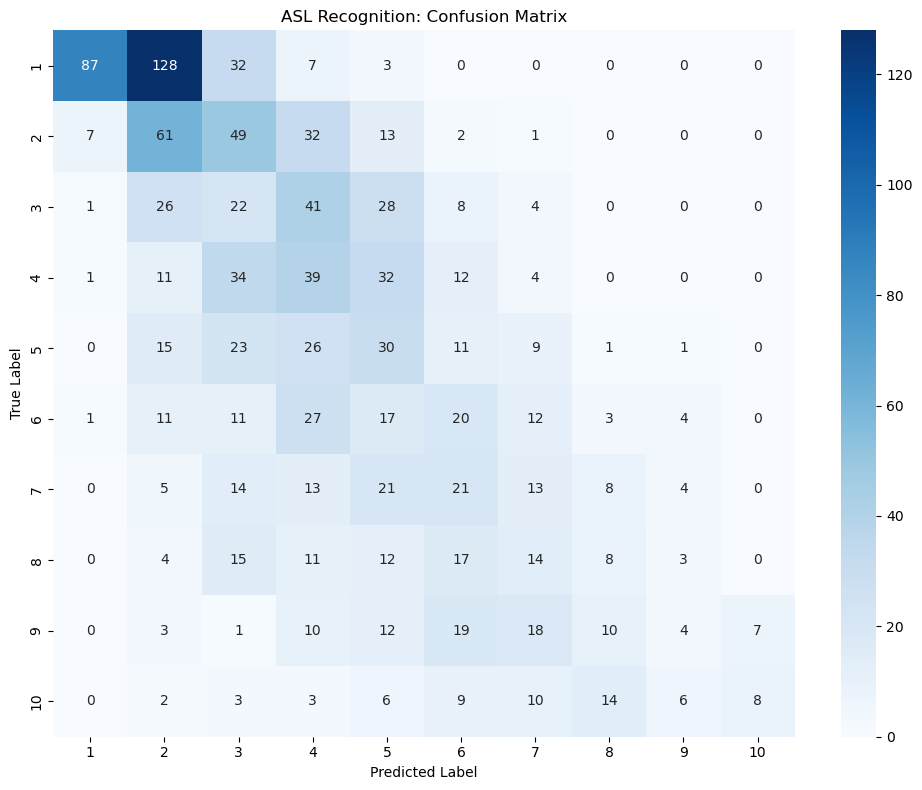

In [21]:
cm = confusion_matrix(y_test, class_y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1,11), yticklabels=range(1,11))

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("ASL Recognition: Confusion Matrix")
plt.tight_layout()
plt.show()

# 4) Learning Curves

> AI Acknowledgement:
- This section was made with the help of Claude Sonnet 4.6. It helps us understand model fit and overfit trends as the data increases. 

> Thoughs and conclusions:
- Random forest achived the highest score in R2 but due to a slight overfit.

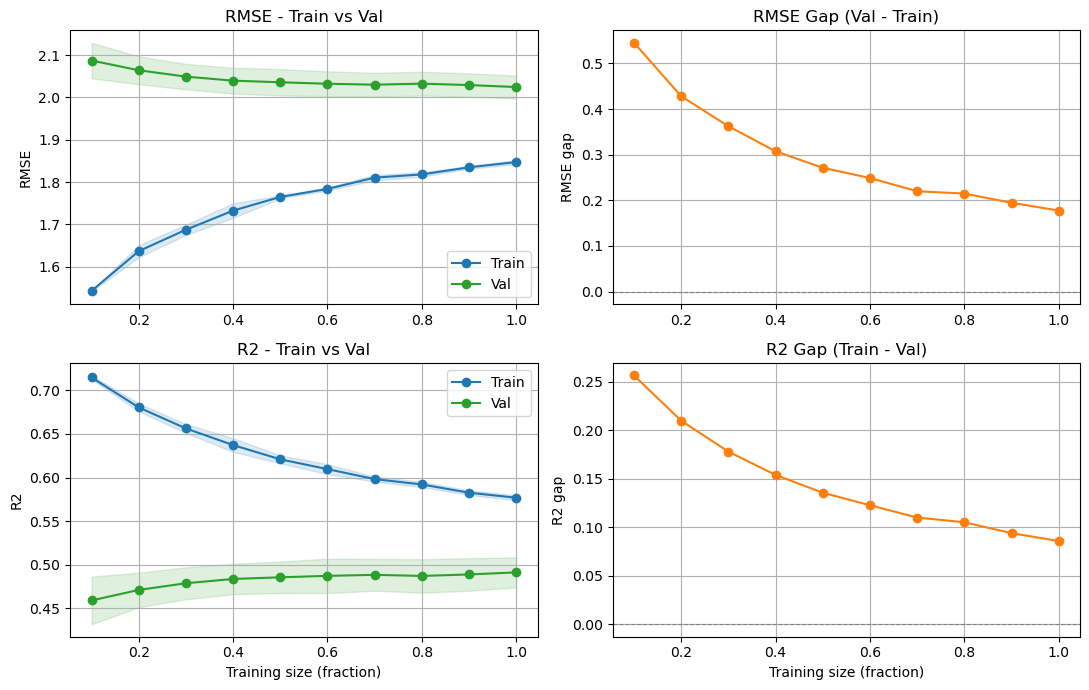

In [22]:
sizes = np.linspace(0.1, 1.0, 10)
lc_model = model_random_forest # Change here to see other models

def _lc(scoring):
    _, tr, vl = learning_curve(
        lc_model.best_estimator_, X, y,
        train_sizes=sizes, cv=5, scoring=scoring, n_jobs=-1
    )
    return tr, vl

tr_mse, vl_mse = _lc('neg_mean_squared_error')
tr_r2,  vl_r2  = _lc('r2')

tr_rmse_m, tr_rmse_s = np.sqrt(-tr_mse).mean(1), np.sqrt(-tr_mse).std(1)
vl_rmse_m, vl_rmse_s = np.sqrt(-vl_mse).mean(1), np.sqrt(-vl_mse).std(1)
tr_r2_m,   tr_r2_s   = tr_r2.mean(1),  tr_r2.std(1)
vl_r2_m,   vl_r2_s   = vl_r2.mean(1),  vl_r2.std(1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# RMSE - Train vs Val
ax = axes[0, 0]
ax.plot(sizes, tr_rmse_m, marker='o', label='Train', color='tab:blue')
ax.plot(sizes, vl_rmse_m, marker='o', label='Val',   color='tab:green')
ax.fill_between(sizes, tr_rmse_m - tr_rmse_s, tr_rmse_m + tr_rmse_s, alpha=0.15, color='tab:blue')
ax.fill_between(sizes, vl_rmse_m - vl_rmse_s, vl_rmse_m + vl_rmse_s, alpha=0.15, color='tab:green')
ax.set_title('RMSE - Train vs Val')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(True)

# RMSE gap
ax = axes[0, 1]
ax.plot(sizes, vl_rmse_m - tr_rmse_m, marker='o', color='tab:orange')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('RMSE Gap (Val - Train)')
ax.set_ylabel('RMSE gap')
ax.grid(True)

# R2 — Train vs Val
ax = axes[1, 0]
ax.plot(sizes, tr_r2_m, marker='o', label='Train', color='tab:blue')
ax.plot(sizes, vl_r2_m, marker='o', label='Val',   color='tab:green')
ax.fill_between(sizes, tr_r2_m - tr_r2_s, tr_r2_m + tr_r2_s, alpha=0.15, color='tab:blue')
ax.fill_between(sizes, vl_r2_m - vl_r2_s, vl_r2_m + vl_r2_s, alpha=0.15, color='tab:green')
ax.set_title('R2 - Train vs Val')
ax.set_ylabel('R2')
ax.set_xlabel('Training size (fraction)')
ax.legend()
ax.grid(True)

# R2 gap
ax = axes[1, 1]
ax.plot(sizes, tr_r2_m - vl_r2_m, marker='o', color='tab:orange')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('R2 Gap (Train - Val)')
ax.set_ylabel('R2 gap')
ax.set_xlabel('Training size (fraction)')
ax.grid(True)

plt.tight_layout()
plt.show()

# 5) Racial Bias Analysis

> AI Acknowledgement:
- This section was made with the help of Claude Sonnet 4.6. It helps us understand model fit and overfit trends as the data increases. 

The central motivation of this project is to investigate whether the COMPAS score embeds racial bias.
Having trained our models, we now examine two questions:
1. Do `race_*` features rank as important predictors in our best model?
2. Does our best model (Random Forest) produce systematically different errors across racial groups?

We use the Random Forest as the reference model since it achieved the highest R² (0.5034).

### Feature Importance (Random Forest)

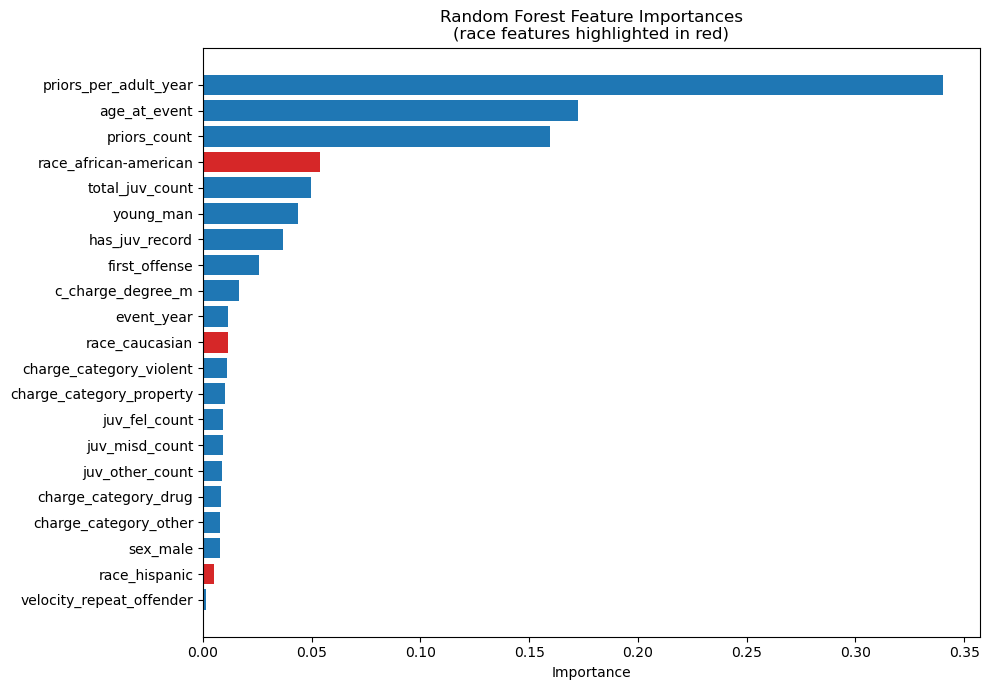

Race feature rankings:
  race_african-american: rank #4 of 21 (0.0539)
  race_caucasian: rank #11 of 21 (0.0114)
  race_hispanic: rank #20 of 21 (0.0052)


In [23]:
rf_estimator = model_random_forest.best_estimator_['randomforestregressor']
feature_names = X.columns.tolist()
importances = rf_estimator.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

race_cols = {'race_caucasian', 'race_hispanic', 'race_african-american'}
colors = ['#d62728' if f in race_cols else '#1f77b4' for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances\n(race features highlighted in red)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Race feature rankings:")
for _, row in importance_df[importance_df['feature'].isin(race_cols)].iterrows():
    rank = importance_df.index[importance_df['feature'] == row['feature']].item() + 1
    print(f"  {row['feature']}: rank #{rank} of {len(feature_names)} ({row['importance']:.4f})")

### Per-Race Error Breakdown

We decode the one-hot encoded race columns back into a single label, then compute prediction errors per group. The **signed error** (predicted − true) reveals directional bias:
- Positive → model systematically over-predicts risk for this group
- Negative → model systematically under-predicts risk

In [24]:
def decode_race(row):
    if row['race_african-american'] == 1:
        return 'african-american'
    elif row['race_caucasian'] == 1:
        return 'caucasian'
    elif row['race_hispanic'] == 1:
        return 'hispanic'
    else:
        return 'other'  # reference category (dropped during encoding)

analysis_df = X_test.copy()
analysis_df['race'] = analysis_df.apply(decode_race, axis=1)
analysis_df['y_true'] = y_test.values
analysis_df['y_pred'] = model_random_forest.predict(X_test)
analysis_df['signed_error'] = analysis_df['y_pred'] - analysis_df['y_true']

In [25]:
race_metrics = analysis_df.groupby('race').apply(lambda g: pd.Series({
    'n': len(g),
    'mean_true_score': round(g['y_true'].mean(), 3),
    'mean_pred_score': round(g['y_pred'].mean(), 3),
    'mae': round(mean_absolute_error(g['y_true'], g['y_pred']), 4),
    'rmse': round(np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])), 4),
    'mean_signed_error': round(g['signed_error'].mean(), 4),
})).reset_index()

display(race_metrics)

/tmp/ipykernel_288764/3622651606.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = analysis_df.groupby('race').apply(lambda g: pd.Series({


,race,n,mean_true_score,mean_pred_score,mae,rmse,mean_signed_error
0,african-american,654.0,5.182,5.209,1.7420,2.1211,0.0266
1,caucasian,416.0,3.541,3.625,1.5104,1.9091,0.0840
2,hispanic,95.0,3.632,3.726,1.4380,1.8889,0.0941
3,other,70.0,3.557,3.809,1.3645,1.7146,0.2523


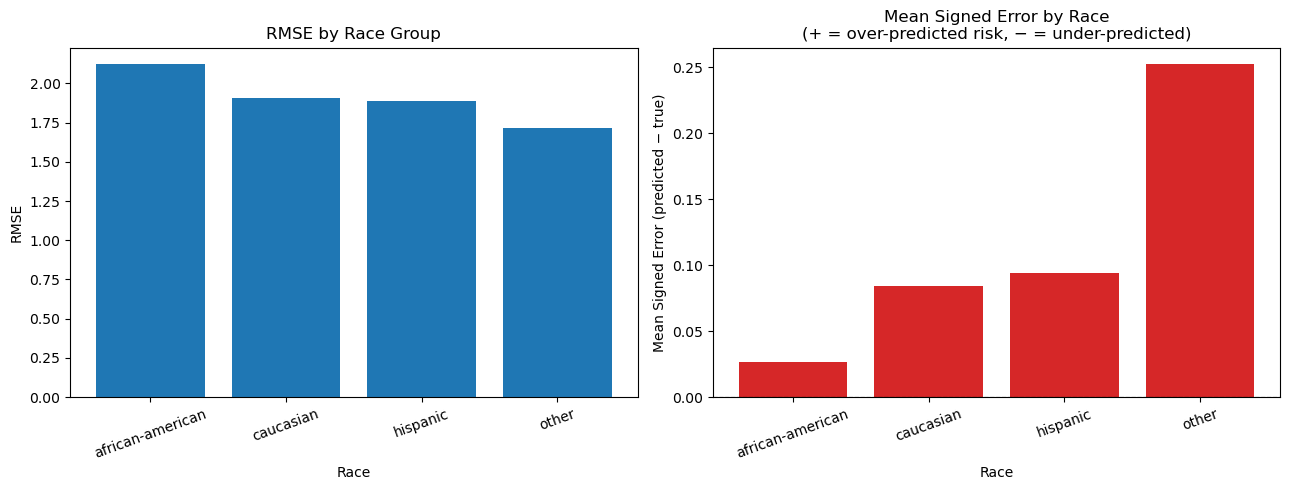

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: RMSE per race
ax = axes[0]
ax.bar(race_metrics['race'], race_metrics['rmse'], color='#1f77b4')
ax.set_title('RMSE by Race Group')
ax.set_ylabel('RMSE')
ax.set_xlabel('Race')
ax.tick_params(axis='x', rotation=20)

# Plot 2: Mean signed error per race (bias direction)
ax = axes[1]
bar_colors = ['#d62728' if v > 0 else '#2ca02c' for v in race_metrics['mean_signed_error']]
ax.bar(race_metrics['race'], race_metrics['mean_signed_error'], color=bar_colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Signed Error by Race\n(+ = over-predicted risk, − = under-predicted)')
ax.set_ylabel('Mean Signed Error (predicted − true)')
ax.set_xlabel('Race')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# 6) Save Models

In [27]:
MODELS_DIR = "../../models/score/w_race"
os.makedirs(MODELS_DIR, exist_ok=True)

models = {
    "elasticnet_polynomial": model_elastic_net,
    "quantile_ttr":          model_quantile,
    "ordinal":               model_ordinal,
    "elasticnet_spline_ttr": model_elasticnet_spline,
    "random_forest":         model_random_forest,
}

for name, model in models.items():
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    print(f"Saved: {path}")

Saved: ../../models/score/w_race/elasticnet_polynomial.joblib
Saved: ../../models/score/w_race/quantile_ttr.joblib
Saved: ../../models/score/w_race/ordinal.joblib
Saved: ../../models/score/w_race/elasticnet_spline_ttr.joblib
Saved: ../../models/score/w_race/random_forest.joblib
